In [1]:
!pip install mplsoccer

  Using cached requests-2.34.2-py3-none-any.whl.metadata (4.8 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached contourpy-1.3.3-cp313-cp313-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
  Using cached charset_normalizer-3.5.1-cp313-cp313-win_amd64.whl.metadata (46 kB)
  Using cached idna-3.19-py3-none-any.whl.metadata (9.2 kB)
  Using cached urllib3-2.7.0-py3-none-any.whl.metadata (6.9 kB)
  Using cached certifi-2026.7.22-py3-none-any.whl.metadata (2.5 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.3 MB 3.3 MB/s eta 0:00:03
   ----- ---------------------------------- 1.3/9.3 MB 3.7 MB/s eta 0:00:03
   -------- ------------------------------- 2.1/9.3 MB 3.8 MB/s eta 0:00:02
   ------------ --------

In [3]:
!pip install bs4

  Using cached beautifulsoup4-4.15.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached soupsieve-2.9.2-py3-none-any.whl.metadata (4.6 kB)
Using cached beautifulsoup4-4.15.0-py3-none-any.whl (109 kB)
Using cached soupsieve-2.9.2-py3-none-any.whl (37 kB)

   ---------------------------------------- 0/3 [soupsieve]
   ------------- -------------------------- 1/3 [beautifulsoup4]
   ------------- -------------------------- 1/3 [beautifulsoup4]
   ---------------------------------------- 3/3 [bs4]



In [5]:
!pip install plotly

   ---------------------------------------- 0.0/9.1 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.1 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.1 MB 2.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.1 MB 2.3 MB/s eta 0:00:04
   -- ------------------------------------- 0.5/9.1 MB 2.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.3/9.1 MB 1.5 MB/s eta 0:00:06
   --------- ------------------------------ 2.1/9.1 MB 1.9 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.1 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.7/9.1 MB 2.4 MB/s eta 0:00:03
   ------------------- -------------------- 4.5/9.1 MB 2.6 MB/s eta 0:00:02
   ----------------------- ---------------- 5.2/9.1 MB 2.8 MB/s eta 0:00:02
   -------------------------- ------------- 6.0/9.1 MB 2.8 MB/s eta 0:00:02
   ------------------------------ --------- 6.8/9.1 MB 2.9 MB/s eta 0:00:01
   -----------------------

In [83]:
!pip install -U ddgs

   ---------------------------------------- 0.0/5.2 MB ? eta -:--:--
   ------ --------------------------------- 0.8/5.2 MB 4.0 MB/s eta 0:00:02
   ------------ --------------------------- 1.6/5.2 MB 3.7 MB/s eta 0:00:01
   ------------------ --------------------- 2.4/5.2 MB 3.8 MB/s eta 0:00:01
   ------------------------ --------------- 3.1/5.2 MB 3.9 MB/s eta 0:00:01
   ------------------------------ --------- 3.9/5.2 MB 3.9 MB/s eta 0:00:01
   -------------------------------------- - 5.0/5.2 MB 3.9 MB/s eta 0:00:01
   ---------------------------------------- 5.2/5.2 MB 3.8 MB/s  0:00:01

   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [ddgs]
   -------------------------- ------------- 2/3 [ddgs]
   -------------------------- ------------- 2/3 [ddgs]
   ---------

In [1]:
import requests
from bs4 import BeautifulSoup
import json
import pandas as pd
from mplsoccer import Pitch, VerticalPitch
import matplotlib.pyplot as plt
from pandas import json_normalize
import matplotlib.dates as mdates
from mplsoccer import Pitch
from mplsoccer import Sbopen
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from urllib.request import urlopen
from mplsoccer import PyPizza, add_image, FontManager
import seaborn as sns
import plotly.graph_objects as go
import re, json



In [35]:
!pip install -r requirements.txt

  Using cached html5lib-1.1-py2.py3-none-any.whl.metadata (16 kB)
  Using cached lxml-6.1.3-cp313-cp313-win_amd64.whl.metadata (3.4 kB)
  Using cached webencodings-0.6.1-py3-none-any.whl.metadata (3.4 kB)
Using cached html5lib-1.1-py2.py3-none-any.whl (112 kB)
Using cached lxml-6.1.3-cp313-cp313-win_amd64.whl (4.0 MB)
Using cached webencodings-0.6.1-py3-none-any.whl (8.7 kB)

   ------------- -------------------------- 1/3 [lxml]
   ------------- -------------------------- 1/3 [lxml]
   -------------------------- ------------- 2/3 [html5lib]
   -------------------------- ------------- 2/3 [html5lib]
   -------------------------- ------------- 2/3 [html5lib]
   ---------------------------------------- 3/3 [html5lib]



In [37]:
def get_page(league: str, season: int) -> dict:
    """
    Fetch Understat league data and return teams dictionary.

    Parameters
    ----------
    league : str
        League code, e.g. 'EPL', 'LaLiga', 'Bundesliga'
    season : int
        Season start year, e.g. 2025

    Returns
    -------
    dict
        data['teams']
    """

    url = f"https://understat.com/getLeagueData/{league}/{season}"

    headers = {
        "Accept": "application/json, text/javascript, */*; q=0.01",
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 (KHTML, like Gecko) "
            "Chrome/120.0.0.0 Safari/537.36"
        ),
        "X-Requested-With": "XMLHttpRequest",
        "Referer": f"https://understat.com/league/{league}/{season}",
    }

    response = requests.get(url, headers=headers, timeout=15)
    response.raise_for_status()

    data = response.json()
    return data['dates']

In [38]:
data = get_page('EPL', 2026)

In [39]:
def get_matches_for_week(league, year):
    data = get_page(league, year)
    matches = []

    for match in data:
        matches.append({
            'home_team': match['h']['title'],
            'away_team': match['a']['title'],
            'home_goals': match['goals']['h'],
            'away_goals': match['goals']['a'],
            'home_xG': match['xG']['h'],
            'away_xG': match['xG']['a'],
            'datetime': match['datetime']
        })

    df = pd.DataFrame(matches)
    df = df[df['home_goals'].notna()].reset_index(drop=True)

    df['home_xG'] = df['home_xG'].astype(float).round(2)
    df['away_xG'] = df['away_xG'].astype(float).round(2)
    
    return df

In [40]:
df = get_matches_for_week('EPL', 2026)

In [41]:
df

,home_team,away_team,home_goals,away_goals,home_xG,away_xG,datetime
0,Arsenal,Coventry,3,0,1.85,0.56,2026-08-21 19:00:00
1,Hull,Manchester United,2,0,1.50,1.78,2026-08-22 11:30:00
2,Everton,Crystal Palace,2,0,1.45,2.23,2026-08-22 14:00:00
3,Ipswich,Sunderland,2,1,1.58,1.18,2026-08-22 14:00:00
4,Nottingham Forest,Leeds,0,1,0.66,0.47,2026-08-22 14:00:00
5,Brentford,Tottenham,3,0,4.04,0.76,2026-08-22 16:30:00
6,Brighton,Aston Villa,4,0,4.00,0.28,2026-08-23 13:00:00
7,Manchester City,Bournemouth,2,1,2.47,0.71,2026-08-23 13:00:00
8,Newcastle United,Liverpool,2,2,1.59,3.13,2026-08-23 15:30:00
9,Fulham,Chelsea,2,3,1.42,2.58,2026-08-24 19:00:00


In [42]:
!pip install understatapi


     ---------------------------------------- 0.0/537.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/537.7 kB ? eta -:--:--
     ---------------------------------------- 537.7/537.7 kB 3.4 MB/s  0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for understatapi: filename=understatapi-0.7.1-py3-none-any.whl size=15474 sha256=6aa49306260a6571f7faa898323ff2a52410e647c37d97473657cc275b1a47dc
  Stored in directory: c:\users\salma\appdata\local\pip\cache\wheels\29\80\82\06d77c7a1324f1db92640d5af17ed2423b1d2c4b3dcedc7aea
Successfully built understatapi

  Attempting uninstall: urllib3

    Found existing installation: urllib3 2.7.0

    Uninstalling urllib3-2.7.0:

      S

  You can safely remove it manually.


In [2]:
from understatapi import UnderstatClient

understat = UnderstatClient()
team_match_data = understat.team(team="Arsenal").get_match_data(season="2026")


In [3]:
matches = team_match_data

In [4]:
match_id = "31199"

In [5]:
roster_data = understat.match(match=match_id).get_roster_data()

In [6]:
roster_data

{'h': {'798265': {'id': '798265',
   'goals': '0',
   'own_goals': '0',
   'shots': '0',
   'xG': '0',
   'time': '90',
   'player_id': '12781',
   'team_id': '71',
   'position': 'GK',
   'player': 'Zion Suzuki',
   'h_a': 'h',
   'yellow_card': '0',
   'red_card': '0',
   'roster_in': '0',
   'roster_out': '0',
   'key_passes': '0',
   'assists': '0',
   'xA': '0',
   'xGChain': '0.0823236033320427',
   'xGBuildup': '0.0823236033320427',
   'positionOrder': '1'},
  '798266': {'id': '798266',
   'goals': '0',
   'own_goals': '0',
   'shots': '1',
   'xG': '0.07843043655157089',
   'time': '79',
   'player_id': '8864',
   'team_id': '71',
   'position': 'DR',
   'player': 'Matthew Cash',
   'h_a': 'h',
   'yellow_card': '0',
   'red_card': '0',
   'roster_in': '798278',
   'roster_out': '0',
   'key_passes': '0',
   'assists': '0',
   'xA': '0',
   'xGChain': '0.12047496438026428',
   'xGBuildup': '0.04204452782869339',
   'positionOrder': '2'},
  '798268': {'id': '798268',
   'goals':

In [7]:
all_players = []
for team_key in ['h', 'a']:
    if team_key in roster_data:
        all_players.extend(roster_data[team_key].values())

In [8]:
pd.set_option('display.max_columns', None)


In [9]:
df = pd.DataFrame(all_players)

| Metric | What it tells you |
|---|---|
| Goals | Actual finishing |
| xG | Quality of chances |
| Shots | Shooting volume |
| xG/Shot | Average shot quality |
| Assists | Actual creation |
| xA | Quality of chances created |
| Key passes | Chance-creation volume |
| xGChain | Involvement in dangerous possessions |
| xGBuildup | Contribution to attacking buildup |
| Yellow/Red cards | Discipline |

In [65]:
df

,id,goals,own_goals,shots,xG,time,player_id,team_id,position,player,h_a,yellow_card,red_card,roster_in,roster_out,key_passes,assists,xA,xGChain,xGBuildup,positionOrder
0,798265,0,0,0,0.000000,90,12781,71,GK,Zion Suzuki,h,0,0,0,0,0,0,0.000000,0.082324,0.082324,1
1,798266,0,0,1,0.078430,79,8864,71,DR,Matthew Cash,h,0,0,798278,0,0,0,0.000000,0.120475,0.042045,2
2,798268,0,0,0,0.000000,90,6080,71,DC,Victor Lindelöf,h,0,0,0,0,0,0,0.000000,0.040279,0.040279,3
3,798267,0,0,0,0.000000,90,6221,71,DC,Pau Torres,h,0,0,0,0,0,0,0.000000,0.040279,0.040279,3
4,798269,0,0,2,0.082324,90,11807,71,DL,Ian Maatsen,h,1,0,0,0,0,0,0.000000,0.109696,0.067652,4
5,798271,0,0,1,0.036060,79,592,71,DMC,Ross Barkley,h,0,0,798276,0,2,0,0.082324,0.145757,0.067652,7
6,798270,0,0,0,0.000000,90,5789,71,DMC,Boubacar Kamara,h,0,0,0,0,1,0,0.027373,0.109696,0.109696,7
7,798272,0,0,2,0.057737,90,7723,71,AMR,John McGinn,h,1,0,0,0,1,0,0.078430,0.178212,0.042045,11
8,798273,0,0,1,0.027373,90,2203,71,AMC,Emiliano Buendía,h,0,0,0,0,1,0,0.020744,0.130441,0.082324,12
9,798274,0,0,0,0.000000,72,14193,71,AML,George Hemmings,h,0,0,798277,0,0,0,0.000000,0.061023,0.061023,13


In [10]:
numeric_cols = [
    'goals',
    'own_goals',
    'shots',
    'xG',
    'time',
    'yellow_card',
    'red_card',
    'key_passes',
    'assists',
    'xA',
    'xGChain',
    'xGBuildup',
    'positionOrder',
]

df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

print(df.head())

       id  goals  own_goals  shots        xG  time player_id team_id position  \
0  798265      0          0      0  0.000000    90     12781      71       GK   
1  798266      0          0      1  0.078430    79      8864      71       DR   
2  798268      0          0      0  0.000000    90      6080      71       DC   
3  798267      0          0      0  0.000000    90      6221      71       DC   
4  798269      0          0      2  0.082324    90     11807      71       DL   

            player h_a  yellow_card  red_card roster_in roster_out  \
0      Zion Suzuki   h            0         0         0          0   
1     Matthew Cash   h            0         0    798278          0   
2  Victor Lindelöf   h            0         0         0          0   
3       Pau Torres   h            0         0         0          0   
4      Ian Maatsen   h            1         0         0          0   

   key_passes  assists   xA   xGChain  xGBuildup  positionOrder  
0           0        0  0.

In [11]:
df.dtypes

id                   str
goals              int64
own_goals          int64
shots              int64
xG               float64
time               int64
player_id            str
team_id              str
position             str
player               str
h_a                  str
yellow_card        int64
red_card           int64
roster_in            str
roster_out           str
key_passes         int64
assists            int64
xA               float64
xGChain          float64
xGBuildup        float64
positionOrder      int64
dtype: object

In [12]:
df["team_id"].unique()

<StringArray>
['71', '83']
Length: 2, dtype: str

In [13]:
df.groupby("team_id").size()

team_id
71    15
83    16
dtype: int64

In [14]:
team_stats = df.groupby("team_id").agg(
    goals=("goals", "sum"),
    shots=("shots", "sum"),
    xG=("xG", "sum"),
    assists=("assists", "sum"),
    xA=("xA", "sum"),
    key_passes=("key_passes", "sum"),
    xGChain=("xGChain", "sum"),
    xGBuildup=("xGBuildup", "sum")
).reset_index()

team_stats

,team_id,goals,shots,xG,assists,xA,key_passes,xGChain,xGBuildup
0,71,0,7,0.281925,0,0.208871,5,1.123986,0.741121
1,83,1,7,1.524407,1,1.106264,5,8.934884,6.857243


In [15]:
team_stats["xG_per_shot"] = team_stats["xG"] / team_stats["shots"]

In [16]:
team_stats["finishing_difference"] = (
    team_stats["goals"] - team_stats["xG"]
)

In [17]:
team_stats.round(2)

,team_id,goals,shots,xG,assists,xA,key_passes,xGChain,xGBuildup,xG_per_shot,finishing_difference
0,71,0,7,0.28,0,0.21,5,1.12,0.74,0.04,-0.28
1,83,1,7,1.52,1,1.11,5,8.93,6.86,0.22,-0.52


In [18]:
team_stats.sort_values("xG", ascending=False)

,team_id,goals,shots,xG,assists,xA,key_passes,xGChain,xGBuildup,xG_per_shot,finishing_difference
1,83,1,7,1.524407,1,1.106264,5,8.934884,6.857243,0.217772,-0.524407
0,71,0,7,0.281925,0,0.208871,5,1.123986,0.741121,0.040275,-0.281925


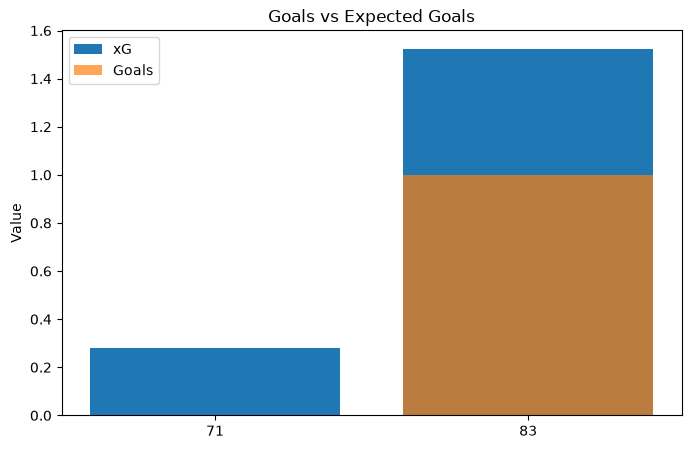

In [19]:

plt.figure(figsize=(8, 5))

x = range(len(team_stats))

plt.bar(
    x,
    team_stats["xG"],
    label="xG"
)

plt.bar(
    x,
    team_stats["goals"],
    alpha=0.7,
    label="Goals"
)

plt.xticks(x, team_stats["team_id"])
plt.ylabel("Value")
plt.title("Goals vs Expected Goals")
plt.legend()

plt.show()

In [20]:
arsenal = df[df["team_id"] == "83"].copy()

top_10 = (
    arsenal
    .sort_values("xG", ascending=False)
    .head(10)
)

top_10[["player", "player_id", "xG", "xA", "shots", "goals"]]

,player,player_id,xG,xA,shots,goals
22,Bukayo Saka,7322,0.975281,0.000000,2,1
18,Gabriel,5613,0.327258,0.000000,1,0
23,Martin Odegaard,2517,0.090885,0.000000,1,0
19,Riccardo Calafiori,8129,0.048702,0.937799,1,0
21,Myles Lewis-Skelly,12272,0.047201,0.000000,1,0
25,Kai Havertz,5220,0.035079,0.000000,1,0
17,Cristhian Mosquera,10024,0.000000,0.000000,0,0
16,Ben White,7298,0.000000,0.035079,0,0
20,Declan Rice,5553,0.000000,0.086185,0,0
15,David Raya,9676,0.000000,0.000000,0,0


In [23]:
arsenal["xGI"] = arsenal["xG"] + arsenal["xA"]

top_10 = (
    arsenal
    .sort_values("xGI", ascending=False)
    .head(10)
)

In [81]:
top_10

,id,goals,own_goals,shots,xG,time,player_id,team_id,position,player,h_a,yellow_card,red_card,roster_in,roster_out,key_passes,assists,xA,xGChain,xGBuildup,positionOrder,xGI
19,798284,0,0,1,0.048702,90,8129,83,DL,Riccardo Calafiori,a,0,0,0,0,1,1,0.937799,0.937799,0.000000,4,0.986501
22,798287,1,0,2,0.975281,90,7322,83,AMR,Bukayo Saka,a,0,0,0,0,0,0,0.000000,1.010361,0.072562,11,0.975281
18,798282,0,0,1,0.327258,90,5613,83,DC,Gabriel,a,0,0,0,0,0,0,0.000000,0.975281,0.975281,3,0.327258
23,798288,0,0,1,0.090885,72,2517,83,AMC,Martin Odegaard,a,0,0,798292,0,0,0,0.000000,0.037483,0.037483,12,0.090885
20,798285,0,0,0,0.000000,86,5553,83,DMC,Declan Rice,a,0,0,798293,0,2,0,0.086185,0.975281,0.937799,7,0.086185
21,798286,0,0,1,0.047201,72,12272,83,DMC,Myles Lewis-Skelly,a,0,0,798291,0,0,0,0.000000,1.022483,0.975281,7,0.047201
24,798289,0,0,0,0.000000,47,9746,83,AML,Christos Tzolis,a,1,0,798294,0,1,0,0.047201,0.047201,0.000000,13,0.047201
16,798281,0,0,0,0.000000,90,7298,83,DR,Ben White,a,0,0,0,0,1,0,0.035079,0.972878,0.937799,2,0.035079
25,798290,0,0,1,0.035079,90,5220,83,FW,Kai Havertz,a,0,0,0,0,0,0,0.000000,0.972878,0.937799,15,0.035079
17,798283,0,0,0,0.000000,80,10024,83,DC,Cristhian Mosquera,a,0,0,798295,0,0,0,0.000000,0.937799,0.937799,3,0.000000


In [24]:
from IPython.display import display, HTML


In [25]:
from ddgs import DDGS
import requests
from pathlib import Path


def search_for_player_image(player, save_folder="images"):
    
    # Create images folder
    Path(save_folder).mkdir(exist_ok=True)
    
    # Search for the player
    query = f"{player} footballer Arsenal"
    
    with DDGS() as ddgs:
        results = list(
            ddgs.images(
                query,
                max_results=1
            )
        )
    
    if not results:
        print(f"No image found for {player}")
        return None
    
    image_url = results[0]["image"]
    
    # Download image
    response = requests.get(
        image_url,
        timeout=10,
        headers={"User-Agent": "Mozilla/5.0"}
    )
    
    if response.status_code != 200:
        print(f"Could not download image for {player}")
        return None
    
    # Safe filename
    filename = "".join(
        c for c in player
        if c.isalnum() or c in " -_"
    ).strip()
    
    path = Path(save_folder) / f"{filename}.jpg"
    
    with open(path, "wb") as f:
        f.write(response.content)
    
    print(f"Downloaded: {player}")
    
    return str(path)

In [89]:
image_path = search_for_player_image("Bukayo Saka")

print(image_path)

Downloaded: Bukayo Saka
images\Bukayo Saka.jpg


In [26]:
top_10[["player", "player_id"]]

,player,player_id
19,Riccardo Calafiori,8129
22,Bukayo Saka,7322
18,Gabriel,5613
23,Martin Odegaard,2517
20,Declan Rice,5553
21,Myles Lewis-Skelly,12272
24,Christos Tzolis,9746
16,Ben White,7298
25,Kai Havertz,5220
17,Cristhian Mosquera,10024


In [27]:
players = {
    8129: "Riccardo Calafiori",
    7322: "Bukayo Saka",
    5613: "Gabriel",
    2517: "Martin Odegaard",
    5553: "Declan Rice",
    12272: "Myles Lewis-Skelly",
    9746: "Christos Tzolis",
    7298: "Ben White",
    5220: "Kai Havertz",
    10024: "Cristhian Mosquera"
}

In [28]:
df[["player", "player_id", "team_id"]].to_string(index=False)

'            player player_id team_id\n       Zion Suzuki     12781      71\n      Matthew Cash      8864      71\n   Victor Lindelöf      6080      71\n        Pau Torres      6221      71\n       Ian Maatsen     11807      71\n      Ross Barkley       592      71\n   Boubacar Kamara      5789      71\n       John McGinn      7723      71\n  Emiliano Buendía      2203      71\n   George Hemmings     14193      71\n   Nicolas Jackson     10048      71\n    Alysson Edward     14446      71\n Aaron Wan-Bissaka      5584      71\nAlejandro Garnacho     10552      71\n     Tammy Abraham       702      71\n        David Raya      9676      83\n         Ben White      7298      83\nCristhian Mosquera     10024      83\n           Gabriel      5613      83\nRiccardo Calafiori      8129      83\n       Declan Rice      5553      83\nMyles Lewis-Skelly     12272      83\n       Bukayo Saka      7322      83\n   Martin Odegaard      2517      83\n   Christos Tzolis      9746      83\n       Kai 

In [29]:
for player in top_10["player"]:

    search_for_player_image(player)


Downloaded: Riccardo Calafiori
Downloaded: Bukayo Saka


KeyboardInterrupt: 

In [30]:
from pathlib import Path

image_folder = Path("images")

top_10["image_path"] = top_10["player"].apply(
    lambda name: str(image_folder / f"{name}.jpg")
)

top_10[["player", "image_path"]]

,player,image_path
19,Riccardo Calafiori,images\Riccardo Calafiori.jpg
22,Bukayo Saka,images\Bukayo Saka.jpg
18,Gabriel,images\Gabriel.jpg
23,Martin Odegaard,images\Martin Odegaard.jpg
20,Declan Rice,images\Declan Rice.jpg
21,Myles Lewis-Skelly,images\Myles Lewis-Skelly.jpg
24,Christos Tzolis,images\Christos Tzolis.jpg
16,Ben White,images\Ben White.jpg
25,Kai Havertz,images\Kai Havertz.jpg
17,Cristhian Mosquera,images\Cristhian Mosquera.jpg


In [32]:

# Columns to color-code
stat_cols = ['goals', 'shots', 'xG', 'assists', 'xA', 'xGI']

# Precompute min/max for normalization
col_ranges = {col: (top_10[col].min(), top_10[col].max()) for col in stat_cols}
def get_color(value, col_min, col_max, base_color=(224, 32, 32)):
    """Interpolate font color between light gray (low) and base_color (high)."""
    if col_max == col_min:
        norm = 0.5
    else:
        norm = (value - col_min) / (col_max - col_min)
    
    # Start color (low values) - light gray
    start = (235, 186, 52)
    # End color (high values) - your base color, e.g. Arsenal red
    end = base_color
    
    r = int(start[0] + (end[0] - start[0]) * norm)
    g = int(start[1] + (end[1] - start[1]) * norm)
    b = int(start[2] + (end[2] - start[2]) * norm)
    
    return f"color: rgb({r},{g},{b}); font-weight: {600 if norm > 0.6 else 400};"

rows = ""

for i, (_, row) in enumerate(top_10.iterrows()):
    row_bg = "#f9f9f9" if i % 2 == 0 else "#ffffff"

    goals_style = get_color(row['goals'], *col_ranges['goals'])
    shots_style = get_color(row['shots'], *col_ranges['shots'])
    xg_style = get_color(row['xG'], *col_ranges['xG'])
    assists_style = get_color(row['assists'], *col_ranges['assists'])
    xa_style = get_color(row['xA'], *col_ranges['xA'])
    xgi_style = get_color(row['xGI'], *col_ranges['xGI'])

    rows += f"""
    <tr style="background-color: {row_bg};"
        onmouseover="this.style.opacity='0.85'"
        onmouseout="this.style.opacity='1'">
        <td style="padding: 8px; text-align:center;">
            <img src="{row['image_path']}"
                 width="42" height="42"
                 style="object-fit: cover; border-radius: 50%; border: 2px solid #ddd;">
        </td>
        <td style="padding: 8px; font-weight: 600; color:#1a1a1a;">{row['player']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {goals_style}">{row['goals']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {shots_style}">{row['shots']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {xg_style}">{row['xG']:.2f}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {assists_style}">{row['assists']}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; {xa_style}">{row['xA']:.2f}</td>
        <td style="padding: 8px; text-align:center; border-radius:4px; font-weight:700; {xgi_style}">{row['xGI']:.2f}</td>
    </tr>
    """

html = f"""
<div style="max-width: 900px; margin: 20px 0; font-family: 'Segoe UI', Arial, sans-serif;">
    <h2 style="color:#e02020; margin-bottom: 4px;">⚽ Arsenal Player Attacking Contribution</h2>
    <p style="color:#777; margin-top:0; font-size:13px;">Top 10 players by attacking output · darker cells = higher values</p>

    <table style="
        border-collapse: collapse;
        width: 100%;
        box-shadow: 0 1px 4px rgba(0,0,0,0.1);
        border-radius: 8px;
        overflow: hidden;
    ">
        <thead>
            <tr style="background-color:#e02020; color:white;">
                <th style="padding:10px;">Photo</th>
                <th style="padding:10px; text-align:left;">Player</th>
                <th style="padding:10px;">Goals</th>
                <th style="padding:10px;">Shots</th>
                <th style="padding:10px;">xG</th>
                <th style="padding:10px;">Assists</th>
                <th style="padding:10px;">xA</th>
                <th style="padding:10px;">xGI</th>
            </tr>
        </thead>
        <tbody>
            {rows}
        </tbody>
    </table>
</div>
"""

display(HTML(html))

Photo,Player,Goals,Shots,xG,Assists,xA,xGI
,Riccardo Calafiori,0,1,0.05,1,0.94,0.99
,Bukayo Saka,1,2,0.98,0,0.00,0.98
,Gabriel,0,1,0.33,0,0.00,0.33
,Martin Odegaard,0,1,0.09,0,0.00,0.09
,Declan Rice,0,0,0.00,0,0.09,0.09
,Myles Lewis-Skelly,0,1,0.05,0,0.00,0.05
,Christos Tzolis,0,0,0.00,0,0.05,0.05
,Ben White,0,0,0.00,0,0.04,0.04
,Kai Havertz,0,1,0.04,0,0.00,0.04
,Cristhian Mosquera,0,0,0.00,0,0.00,0.00


In [105]:
%pip install --upgrade nbformat

  Using cached nbformat-5.11.1-py3-none-any.whl.metadata (3.7 kB)
  Using cached fastjsonschema-2.22.2-py3-none-any.whl.metadata (2.1 kB)
  Using cached jsonschema-4.26.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached attrs-26.1.0-py3-none-any.whl.metadata (8.8 kB)
  Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl.metadata (2.9 kB)
  Using cached referencing-0.37.0-py3-none-any.whl.metadata (2.8 kB)
  Using cached rpds_py-2026.6.3-cp313-cp313-win_amd64.whl.metadata (4.2 kB)
Using cached nbformat-5.11.1-py3-none-any.whl (79 kB)
Using cached fastjsonschema-2.22.2-py3-none-any.whl (27 kB)
Using cached jsonschema-4.26.0-py3-none-any.whl (90 kB)
Using cached attrs-26.1.0-py3-none-any.whl (67 kB)
Using cached jsonschema_specifications-2025.9.1-py3-none-any.whl (18 kB)
Using cached referencing-0.37.0-py3-none-any.whl (26 kB)
Using cached rpds_py-2026.6.3-cp313-cp313-win_amd64.whl (219 kB)

   ----- ---------------------------------- 1/7 [fastjsonschema]
   ----------- ----

In [109]:
%pip install "jupyterlab>=3" "ipywidgets>=7.6"


  Using cached jupyterlab-4.6.3-py3-none-any.whl.metadata (16 kB)
  Using cached async_lru-2.3.0-py3-none-any.whl.metadata (7.6 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached jupyter_builder-1.2.2-py3-none-any.whl.metadata (7.7 kB)
  Using cached jupyter_lsp-2.3.1-py3-none-any.whl.metadata (1.8 kB)
  Using cached jupyterlab_server-2.28.0-py3-none-any.whl.metadata (5.9 kB)
  Using cached notebook_shim-0.2.4-py3-none-any.whl.metadata (4.0 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached argon2_cffi-25.1.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached jupyter_events-0.12.1-py3-none-any.whl.metadata (5.8 kB)
  Using cached jupyter_server_terminals-0.5.4-py3-none-any.whl.metadata (5.9 kB)
  Using cached nbconvert-7.17.1-py3-none-any.whl.metadata (8.4 kB)
  Using cached prometheus_client-0.26.0-py3

In [112]:
import plotly.graph_objects as go
import numpy as np
from PIL import Image, ImageDraw
import base64
from io import BytesIO
import requests

def make_circular_image(image_path_or_url, size=100):
    """Crop an image into a circle with transparent background, return as base64 data URI."""
    # Load image (handles both local paths and URLs)
    if image_path_or_url.startswith("http"):
        response = requests.get(image_path_or_url)
        img = Image.open(BytesIO(response.content)).convert("RGBA")
    else:
        img = Image.open(image_path_or_url).convert("RGBA")

    # Resize to a square
    img = img.resize((size, size), Image.LANCZOS)

    # Create circular mask
    mask = Image.new("L", (size, size), 0)
    draw = ImageDraw.Draw(mask)
    draw.ellipse((0, 0, size, size), fill=255)

    # Apply mask as alpha channel
    circular_img = Image.new("RGBA", (size, size))
    circular_img.paste(img, (0, 0), mask=mask)

    # Convert to base64 data URI
    buffer = BytesIO()
    circular_img.save(buffer, format="PNG")
    encoded = base64.b64encode(buffer.getvalue()).decode()
    return f"data:image/png;base64,{encoded}"

# --- Setup ---
x_col, y_col = 'xG', 'xA'
x_vals = top_10[x_col].values
y_vals = top_10[y_col].values
players = top_10['player'].values
images = top_10['image_path'].values

# Pre-process all images into circular base64 versions
circular_images = [make_circular_image(img, size=100) for img in images]

x_mid = np.median(x_vals)
y_mid = np.median(y_vals)

fig = go.Figure()

# --- Invisible scatter for hover tooltips ---
fig.add_trace(go.Scatter(
    x=x_vals,
    y=y_vals,
    mode='markers',
    marker=dict(size=28, color='rgba(0,0,0,0)'),
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>" +
        "xG: %{x:.2f}<br>" +
        "xA: %{y:.2f}<extra></extra>"
    ),
    customdata=np.stack([players], axis=-1),
    showlegend=False
))

# --- Add circular player photos, smaller now ---
for xi, yi, img in zip(x_vals, y_vals, circular_images):
    fig.add_layout_image(
        dict(
            source=img,
            x=xi,
            y=yi,
            xref="x", yref="y",
            sizex=(max(x_vals) - min(x_vals)) * 0.07,   # smaller than before (was 0.12)
            sizey=(max(y_vals) - min(y_vals)) * 0.07,
            xanchor="center",
            yanchor="middle",
            layer="above"
        )
    )

# --- Quadrant divider lines ---
fig.add_shape(type="line", x0=x_mid, x1=x_mid, y0=min(y_vals)*0.9, y1=max(y_vals)*1.1,
              line=dict(color="rgba(255,255,255,0.25)", width=1, dash="dot"))
fig.add_shape(type="line", x0=min(x_vals)*0.9, x1=max(x_vals)*1.1, y0=y_mid, y1=y_mid,
              line=dict(color="rgba(255,255,255,0.25)", width=1, dash="dot"))

# --- Quadrant labels ---
fig.add_annotation(x=max(x_vals)*1.05, y=max(y_vals)*1.08, text="COMPLETE",
                    showarrow=False, font=dict(color="#2ee6a6", size=13, family="Arial Black"),
                    xanchor="right")
fig.add_annotation(x=min(x_vals)*0.95, y=min(y_vals)*0.85, text="STRUGGLING",
                    showarrow=False, font=dict(color="#e04b4b", size=13, family="Arial Black"),
                    xanchor="left")

# --- Axis end labels ---
fig.add_annotation(x=min(x_vals)*0.95, y=max(y_vals)*1.08, text="↑ xA",
                    showarrow=False, font=dict(color="#aaaaaa", size=12), xanchor="left")
fig.add_annotation(x=max(x_vals)*1.05, y=min(y_vals)*0.85, text="xG →",
                    showarrow=False, font=dict(color="#aaaaaa", size=12), xanchor="right")

# --- Layout / dark theme ---
fig.update_layout(
    title=dict(text="Arsenal Players — Attack × Creativity (xG × xA)",
               font=dict(color="white", size=20), x=0.02),
    plot_bgcolor="#0e1117",
    paper_bgcolor="#0e1117",
    xaxis=dict(showgrid=False, zeroline=False, visible=False,
               range=[min(x_vals)*0.85, max(x_vals)*1.15]),
    yaxis=dict(showgrid=False, zeroline=False, visible=False,
               range=[min(y_vals)*0.8, max(y_vals)*1.15]),
    width=750,
    height=550,
    margin=dict(l=40, r=40, t=60, b=40),
    hoverlabel=dict(bgcolor="#1c1f26", font_size=13, font_color="white")
)

fig

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

Figure({
    'data': [{'customdata': array([['Riccardo Calafiori'],
                                   ['Bukayo Saka'],
                                   ['Gabriel'],
                                   ['Martin Odegaard'],
                                   ['Declan Rice'],
                                   ['Myles Lewis-Skelly'],
                                   ['Christos Tzolis'],
                                   ['Ben White'],
                                   ['Kai Havertz'],
                                   ['Cristhian Mosquera']], dtype=object),
              'hovertemplate': '<b>%{customdata[0]}</b><br>xG: %{x:.2f}<br>xA: %{y:.2f}<extra></extra>',
              'marker': {'color': 'rgba(0,0,0,0)', 'size': 28},
              'mode': 'markers',
              'showlegend': False,
              'type': 'scatter',
              'x': {'bdata': ('9///P4HvqD////9fgTXvPwAAAGDN8d' ... 'AAAAAAAP3//z/u9aE/AAAAAAAAAAA='),
                    'dtype': 'f8'},
              'y': {'bdata': ('AQAAYHIC7j8AAAAAAAAAAAAAAAAAAA' ... '8/7vWhPwAAAAAAAAAAAAAAAAAAAAA='),
                    'dtype': 'f8'}}],
    'layout': {'annotations': [{'font': {'color': '#2ee6a6', 'family': 'Arial Black', 'size': 13},
                                'showarrow': False,
                                'text': 'COMPLETE',
                                'x': np.float64(1.0240454882383345),
                                'xanchor': 'right',
                                'y': np.float64(1.0128225731849672)},
                               {'font': {'color': '#e04b4b', 'family': 'Arial Black', 'size': 13},
                                'showarrow': False,
                                'text': 'STRUGGLING',
                                'x': np.float64(0.0),
                                'xanchor': 'left',
                                'y': np.float64(0.0)},
                               {'font': {'color': '#aaaaaa', 'size': 12},
                                'showarrow': False,
                                'text': '↑ xA',
                                'x': np.float64(0.0),
                                'xanchor': 'left',
                                'y': np.float64(1.0128225731849672)},
                               {'font': {'color': '#aaaaaa', 'size': 12},
                                'showarrow': False,
                                'text': 'xG →',
                                'x': np.float64(1.0240454882383345),
                                'xanchor': 'right',
                                'y': np.float64(0.0)}],
               'height': 550,
               'hoverlabel': {'bgcolor': '#1c1f26', 'font': {'color': 'white', 'size': 13}},
               'images': [{'layer': 'above',
                           'sizex': np.float64(0.06826969921588898),
                           'sizey': np.float64(0.06564590752124788),
                           'source': ('data:image/png;base64,iVBORw0K' ... '8F7ztz5asaa5UAAAAASUVORK5CYII='),
                           'x': np.float64(0.0487022772431373),
                           'xanchor': 'center',
                           'xref': 'x',
                           'y': np.float64(0.9377986788749696),
                           'yanchor': 'middle',
                           'yref': 'y'},
                          {'layer': 'above',
                           'sizex': np.float64(0.06826969921588898),
                           'sizey': np.float64(0.06564590752124788),
                           'source': ('data:image/png;base64,iVBORw0K' ... '8vjkNT+Hdt8/QAAAAASUVORK5CYII='),
                           'x': np.float64(0.9752814173698424),
                           'xanchor': 'center',
                           'xref': 'x',
                           'y': np.float64(0.0),
                           'yanchor': 'middle',
                           'yref': 'y'},
                          {'layer': 'above',
                           'sizex': np.float64(0.06826969921588898),
       

In [34]:
pip install adjustText

Note: you may need to restart the kernel to use updated packages.


In [35]:
from adjustText import adjust_text

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


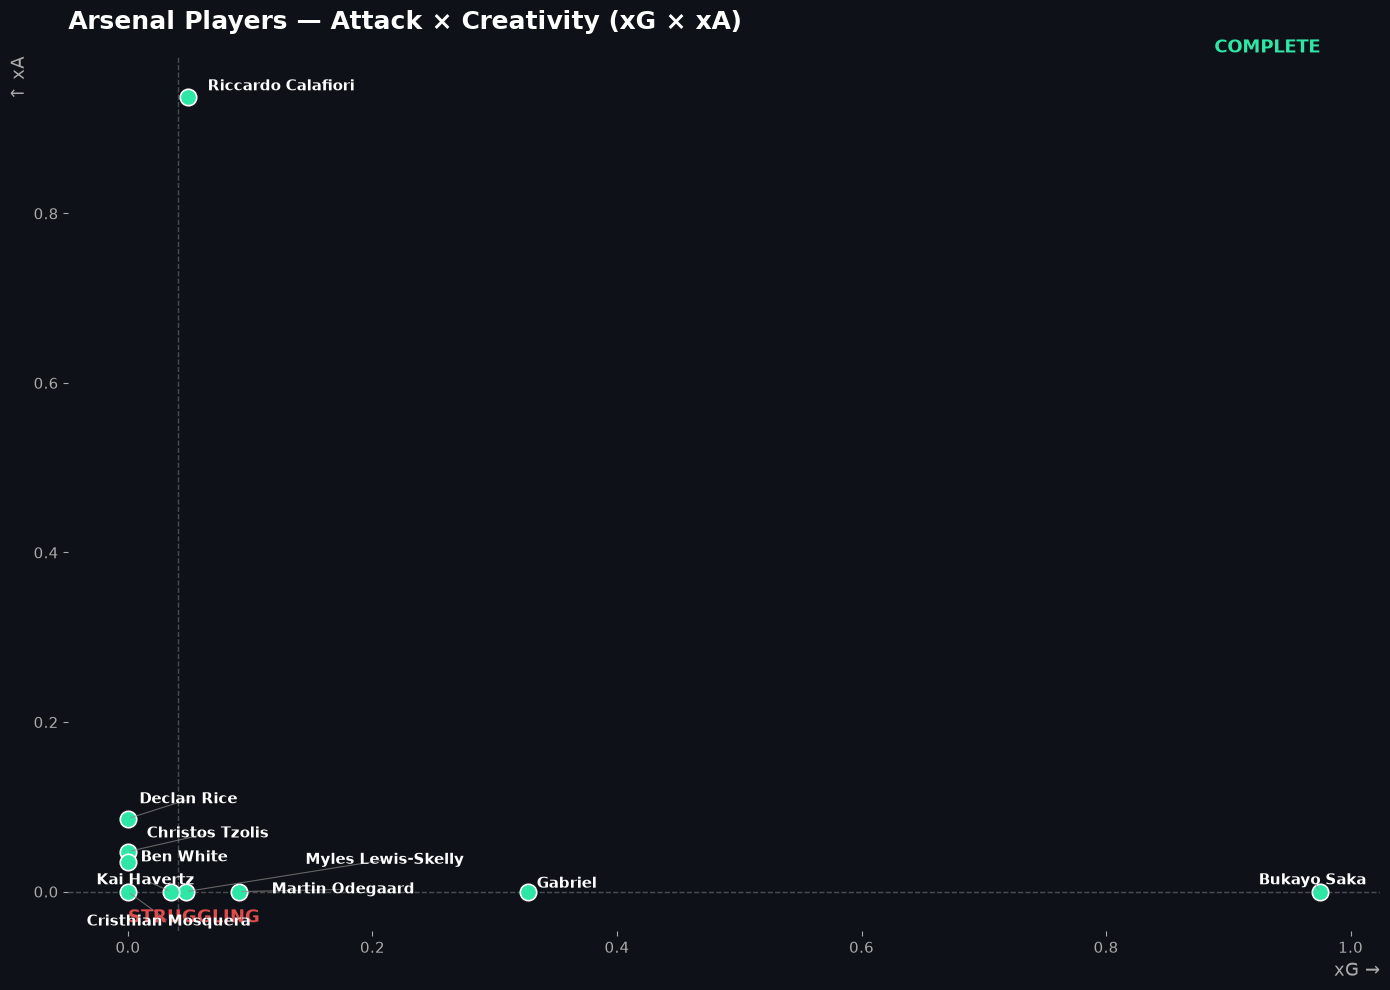

In [36]:


x_col, y_col = 'xG', 'xA'
x_vals = top_10[x_col].values
y_vals = top_10[y_col].values
players = top_10['player'].values

x_mid = np.median(x_vals)
y_mid = np.median(y_vals)

# --- Bigger figure ---
fig, ax = plt.subplots(figsize=(14, 10), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

# --- Scatter points ---
ax.scatter(x_vals, y_vals, s=140, color="#2ee6a6", edgecolors="white",
           linewidths=1.2, zorder=3)

# --- Create text objects (no manual offset yet — adjustText will position them) ---
texts = []
for xi, yi, name in zip(x_vals, y_vals, players):
    texts.append(
        ax.text(xi, yi, name, fontsize=11, color="white", fontweight="bold", zorder=4)
    )

# --- Auto-adjust labels to avoid overlap, with connecting lines to their point ---
adjust_text(
    texts,
    ax=ax,
    arrowprops=dict(arrowstyle="-", color="#888888", lw=0.8, alpha=0.7),
    expand_points=(1.5, 1.5),
    force_text=(0.5, 0.7),
)

# --- Quadrant divider lines ---
ax.axvline(x_mid, color="white", linestyle="--", alpha=0.25, linewidth=1)
ax.axhline(y_mid, color="white", linestyle="--", alpha=0.25, linewidth=1)

# --- Quadrant labels ---
ax.text(max(x_vals), max(y_vals)*1.05, "COMPLETE", color="#2ee6a6",
        fontsize=13, fontweight="bold", ha="right", va="bottom")
ax.text(min(x_vals), min(y_vals)*0.9 - 0.02, "STRUGGLING", color="#e04b4b",
        fontsize=13, fontweight="bold", ha="left", va="top")

# --- Axis labels ---
ax.set_xlabel("xG →", color="#aaaaaa", fontsize=13, loc="right")
ax.set_ylabel("↑ xA", color="#aaaaaa", fontsize=13, loc="top")

# --- Styling ---
for spine in ax.spines.values():
    spine.set_visible(False)
ax.tick_params(colors="#aaaaaa", labelsize=11)
ax.set_title("Arsenal Players — Attack × Creativity (xG × xA)",
             color="white", fontsize=18, fontweight="bold", loc="left", pad=20)

plt.tight_layout()
plt.show()

Who was the biggest goal threat?

In [38]:
df["xG_overperformance"] = df["goals"] - df["xG"]

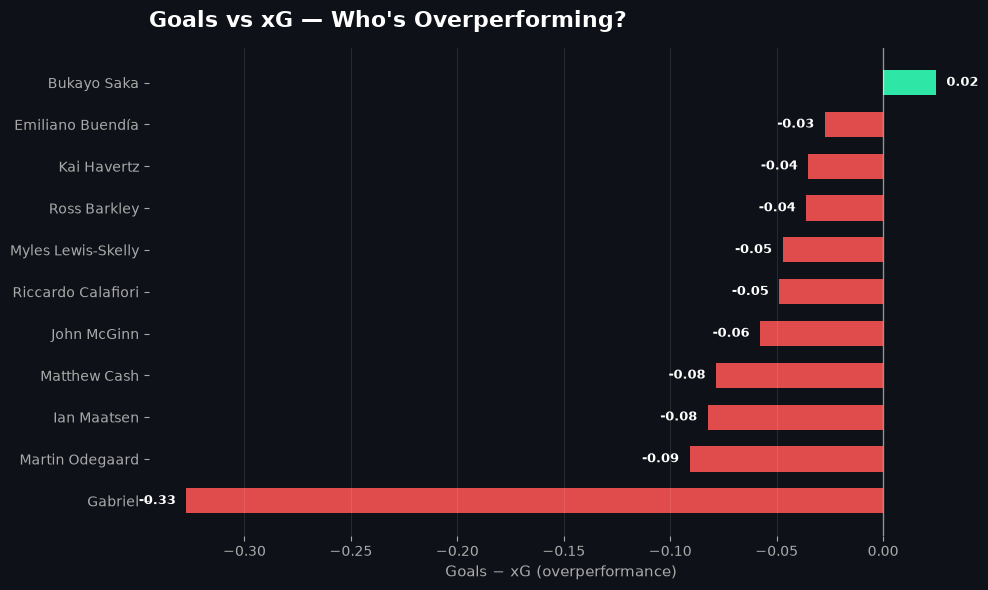

In [46]:

# Sort so biggest overperformers are at top
plot_df = df[df["xG_overperformance"] != 0].sort_values("xG_overperformance", ascending=True)
# Optional: limit to top N (e.g. top 15 by absolute over/underperformance)
# plot_df = df.reindex(df["xG_overperformance"].abs().sort_values(ascending=False).index).head(15)
# plot_df = plot_df.sort_values("xG_overperformance", ascending=True)

colors = ["#2ee6a6" if v >= 0 else "#e04b4b" for v in plot_df["xG_overperformance"]]

fig, ax = plt.subplots(figsize=(10, max(6, len(plot_df) * 0.35)), facecolor="#0e1117")
ax.set_facecolor("#0e1117")

bars = ax.barh(plot_df["player"], plot_df["xG_overperformance"], color=colors, height=0.6)

# Zero line for reference
ax.axvline(0, color="white", linewidth=1, alpha=0.5)

# Value labels at the end of each bar
for bar, val in zip(bars, plot_df["xG_overperformance"]):
    ax.text(
        val + (0.005 if val >= 0 else -0.005),
        bar.get_y() + bar.get_height() / 2,
        f"{val:.2f}",
        va="center",
        ha="left" if val >= 0 else "right",
        color="white",
        fontsize=9,
        fontweight="bold"
    )

# Styling
ax.set_title("Goals vs xG — Who's Overperforming?", color="white", 
             fontsize=16, fontweight="bold", loc="left", pad=15)
ax.set_xlabel("Goals − xG (overperformance)", color="#aaaaaa", fontsize=11)
ax.tick_params(colors="#aaaaaa", labelsize=10)
for spine in ax.spines.values():
    spine.set_visible(False)
ax.grid(axis="x", color="white", alpha=0.1)

plt.tight_layout()
plt.show()